In [7]:
# Cell 1 — Imports
!pip install lightgbm xgboost -q

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, gc, os, glob
warnings.filterwarnings('ignore')

import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

print('LightGBM:', lgb.__version__, '| XGBoost:', xgb.__version__)

LightGBM: 4.4.0 | XGBoost: 2.1.0


In [9]:
# Cell 2 — Memory helper
def reduce_mem(df, verbose=True):
    start = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        dtype = df[col].dtype
        if str(dtype) in ['int64','int32','int16','int8']:
            df[col] = pd.to_numeric(df[col], downcast='integer')
        elif str(dtype) in ['float64','float32']:
            df[col] = pd.to_numeric(df[col], downcast='float')
    end = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'  Memory: {start:.1f}MB -> {end:.1f}MB ({100*(start-end)/start:.0f}% reduction)')
    return df

In [10]:
# Cell 3 — Load data
matches = glob.glob('../Data/application_train.csv', recursive=True)
if not matches:
    raise FileNotFoundError('Dataset not found. Add Home Credit data as input.')
INPUT = os.path.dirname(matches[0])
print(f'Dataset: {INPUT}')
print('Files:', sorted(os.listdir(INPUT)))

app_train = pd.read_csv(f'{INPUT}/application_train.csv')
app_test  = pd.read_csv(f'{INPUT}/application_test.csv')
print(f'Train: {app_train.shape}  |  Test: {app_test.shape}')
print(f'Default rate: {app_train["TARGET"].mean():.3%}')

Dataset: ../Data
Files: ['HomeCredit_columns_description.csv', 'POS_CASH_balance.csv', 'application_test.csv', 'application_train.csv', 'bureau.csv', 'bureau_balance.csv', 'credit_card_balance.csv', 'installments_payments.csv', 'previous_application.csv', 'sample_submission.csv']
Train: (307511, 122)  |  Test: (48744, 121)
Default rate: 8.073%


In [22]:
app_train.head()

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,INST_PAYMENT_RATIO_MAX,INST_DAYS_DIFF_MEAN,INST_DAYS_DIFF_MAX,INST_DAYS_DIFF_STD,INST_LATE_PAYMENT_SUM,INST_LATE_PAYMENT_MEAN,INST_PAID_OVER_SUM,INST_PAID_OVER_MEAN,INST_DAYS_INSTALMENT_MEAN,INST_NUM_INSTALMENT_VERSION_MEAN
0,0,1,0,1,0,202500.0,406597.5,24700.5,351000.0,6,...,0.999981,-20.421053,-12.0,4.925171,0.0,0.000000,0.0,0.0,-295.000000,1.052632
1,0,0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,1,...,0.999998,-7.160000,-1.0,3.726929,0.0,0.000000,0.0,0.0,-1378.160034,1.040000
2,1,1,1,1,0,67500.0,135000.0,6750.0,135000.0,6,...,0.999905,-7.666667,-3.0,4.163332,0.0,0.000000,0.0,0.0,-754.000000,1.333333
3,0,0,0,1,0,135000.0,312682.5,29686.5,297000.0,6,...,0.999999,-19.375000,-1.0,25.397835,0.0,0.000000,0.0,0.0,-252.250000,1.125000
4,0,1,0,1,0,121500.0,513000.0,21865.5,513000.0,6,...,0.999956,-3.636364,12.0,7.991604,16.0,0.242424,0.0,0.0,-1028.606079,1.166667


In [26]:
print(list(app_train.columns))

['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_

In [11]:
# Cell 4 — Application feature engineering
def application_features(df):
    df = df.copy()
    # Basic ratios
    df['CREDIT_INCOME_RATIO']      = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
    df['ANNUITY_INCOME_RATIO']     = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
    df['CREDIT_ANNUITY_RATIO']     = df['AMT_CREDIT'] / (df['AMT_ANNUITY'] + 1)
    df['CREDIT_GOODS_RATIO']       = df['AMT_CREDIT'] / (df['AMT_GOODS_PRICE'] + 1)
    df['GOODS_INCOME_RATIO']       = df['AMT_GOODS_PRICE'] / (df['AMT_INCOME_TOTAL'] + 1)
    df['INCOME_PER_PERSON']        = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)
    df['INCOME_PER_CHILD']         = df['AMT_INCOME_TOTAL'] / (df['CNT_CHILDREN'] + 1)
    # Age/employment
    df['EMPLOYED_TO_BIRTH_RATIO']  = df['DAYS_EMPLOYED'] / (df['DAYS_BIRTH'] + 1)
    df['DAYS_EMPLOYED_PERC']       = df['DAYS_EMPLOYED'] / (df['DAYS_BIRTH'] + 1)
    df['CAR_TO_BIRTH_RATIO']       = df['OWN_CAR_AGE'] / ((-df['DAYS_BIRTH'] / 365) + 1)
    df['PHONE_TO_BIRTH_RATIO']     = df['DAYS_LAST_PHONE_CHANGE'] / (df['DAYS_BIRTH'] + 1)
    df['PHONE_TO_EMPLOY_RATIO']    = df['DAYS_LAST_PHONE_CHANGE'] / (df['DAYS_EMPLOYED'] + 1)
    # External sources (strongest predictors)
    df['EXT_SOURCE_MEAN']          = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)
    df['EXT_SOURCE_STD']           = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].std(axis=1)
    df['EXT_SOURCE_PROD']          = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']
    df['EXT_SOURCE_MIN']           = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].min(axis=1)
    df['EXT_SOURCE_MAX']           = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].max(axis=1)
    df['EXT12']                    = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2']
    df['EXT13']                    = df['EXT_SOURCE_1'] * df['EXT_SOURCE_3']
    df['EXT23']                    = df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']
    # Document flags: count how many docs submitted
    doc_cols = [c for c in df.columns if 'FLAG_DOCUMENT' in c]
    df['DOCS_COUNT']               = df[doc_cols].sum(axis=1)
    # Flag: anomalous employment (365243 = not employed)
    df['EMPLOYED_IS_ANOMALY']      = (df['DAYS_EMPLOYED'] == 365243).astype(int)
    df['DAYS_EMPLOYED']            = df['DAYS_EMPLOYED'].replace(365243, np.nan)
    # Credit term
    df['CREDIT_TERM']              = df['AMT_ANNUITY'] / (df['AMT_CREDIT'] + 1)
    # Social circle anomaly
    df['OBS_DEF_RATIO_30']         = df['DEF_30_CNT_SOCIAL_CIRCLE'] / (df['OBS_30_CNT_SOCIAL_CIRCLE'] + 1)
    df['OBS_DEF_RATIO_60']         = df['DEF_60_CNT_SOCIAL_CIRCLE'] / (df['OBS_60_CNT_SOCIAL_CIRCLE'] + 1)
    return df

app_train = application_features(app_train)
app_test  = application_features(app_test)
print(f'Application shape: {app_train.shape}')

Application shape: (307511, 147)


In [12]:
# Cell 5 — bureau.csv
bureau = pd.read_csv(f'{INPUT}/bureau.csv')
print(f'bureau: {bureau.shape}')

bureau['IS_ACTIVE']         = (bureau['CREDIT_ACTIVE'] == 'Active').astype(int)
bureau['IS_CLOSED']         = (bureau['CREDIT_ACTIVE'] == 'Closed').astype(int)
bureau['IS_BAD']            = (bureau['CREDIT_ACTIVE'] == 'Bad debt').astype(int)
bureau['OVERDUE_RATIO']     = bureau['AMT_CREDIT_SUM_OVERDUE'] / (bureau['AMT_CREDIT_SUM'] + 1)
bureau['DEBT_RATIO']        = bureau['AMT_CREDIT_SUM_DEBT'] / (bureau['AMT_CREDIT_SUM'] + 1)
bureau['CREDIT_ENDDATE_DIFF'] = bureau['DAYS_CREDIT_ENDDATE'] - bureau['DAYS_CREDIT']

agg = bureau.groupby('SK_ID_CURR').agg({
    'SK_ID_BUREAU':             'count',
    'CREDIT_TYPE':              'nunique',
    'IS_ACTIVE':                ['sum','mean'],
    'IS_CLOSED':                ['sum','mean'],
    'IS_BAD':                   ['sum','mean'],
    'AMT_CREDIT_SUM_DEBT':      ['sum','mean','max'],
    'AMT_CREDIT_SUM':           ['sum','mean','max'],
    'AMT_CREDIT_SUM_OVERDUE':   ['sum','max'],
    'AMT_CREDIT_SUM_LIMIT':     ['mean','max'],
    'DAYS_CREDIT':              ['mean','min','max','std'],
    'DAYS_CREDIT_ENDDATE':      ['mean','max'],
    'DAYS_CREDIT_UPDATE':       'mean',
    'AMT_ANNUITY':              ['mean','sum','max'],
    'CNT_CREDIT_PROLONG':       'sum',
    'OVERDUE_RATIO':            'mean',
    'DEBT_RATIO':               'mean',
    'CREDIT_ENDDATE_DIFF':      'mean',
})
agg.columns = ['BUREAU_' + '_'.join(c).upper() for c in agg.columns]
agg = agg.reset_index()

agg['BUREAU_DEBT_CREDIT_RATIO']  = agg['BUREAU_AMT_CREDIT_SUM_DEBT_SUM'] / (agg['BUREAU_AMT_CREDIT_SUM_SUM'] + 1)
agg['BUREAU_ACTIVE_RATIO']       = agg['BUREAU_IS_ACTIVE_SUM'] / (agg['BUREAU_SK_ID_BUREAU_COUNT'] + 1)
agg['BUREAU_OVERDUE_CREDIT_RATIO'] = agg['BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM'] / (agg['BUREAU_AMT_CREDIT_SUM_SUM'] + 1)

app_train = app_train.merge(agg, on='SK_ID_CURR', how='left')
app_test  = app_test.merge(agg,  on='SK_ID_CURR', how='left')
print(f'After bureau merge: {app_train.shape}')
del bureau, agg; gc.collect()

bureau: (1716428, 17)
After bureau merge: (307511, 182)


0

In [13]:
# Cell 6 — bureau_balance.csv
bb = pd.read_csv(f'{INPUT}/bureau_balance.csv')
print(f'bureau_balance: {bb.shape}')

bb_dummies = pd.get_dummies(bb['STATUS'], prefix='BB_STATUS')
bb = pd.concat([bb[['SK_ID_BUREAU','MONTHS_BALANCE']], bb_dummies], axis=1)
status_cols = [c for c in bb.columns if c.startswith('BB_STATUS_')]

agg_dict = {'MONTHS_BALANCE': ['count','min','max']}
for c in status_cols:
    agg_dict[c] = 'mean'
bb_bureau = bb.groupby('SK_ID_BUREAU').agg(agg_dict)
bb_bureau.columns = ['BB_MONTHS_COUNT','BB_MONTHS_MIN','BB_MONTHS_MAX'] + [c+'_MEAN' for c in status_cols]
bb_bureau = bb_bureau.reset_index()

bureau_key = pd.read_csv(f'{INPUT}/bureau.csv', usecols=['SK_ID_BUREAU','SK_ID_CURR'])
bb_bureau = bb_bureau.merge(bureau_key, on='SK_ID_BUREAU', how='left')

mean_cols = [c+'_MEAN' for c in status_cols]
client_dict = {'BB_MONTHS_COUNT':['mean','sum'], 'BB_MONTHS_MIN':'min', 'BB_MONTHS_MAX':'max'}
for c in mean_cols:
    client_dict[c] = ['mean','max']
bb_client = bb_bureau.drop('SK_ID_BUREAU',axis=1).groupby('SK_ID_CURR').agg(client_dict)
bb_client.columns = ['BB_CLIENT_'+'_'.join(c).upper() for c in bb_client.columns]
bb_client = bb_client.reset_index()

app_train = app_train.merge(bb_client, on='SK_ID_CURR', how='left')
app_test  = app_test.merge(bb_client,  on='SK_ID_CURR', how='left')
print(f'After bureau_balance merge: {app_train.shape}')
del bb, bb_dummies, bb_bureau, bureau_key, bb_client; gc.collect()

bureau_balance: (27299925, 3)
After bureau_balance merge: (307511, 202)


0

In [14]:
# Cell 7 — previous_application.csv  ← KEY NEW TABLE
prev = pd.read_csv(f'{INPUT}/previous_application.csv')
print(f'previous_application: {prev.shape}')

# Replace anomalous values
prev['DAYS_FIRST_DRAWING'].replace(365243, np.nan, inplace=True)
prev['DAYS_FIRST_DUE'].replace(365243, np.nan, inplace=True)
prev['DAYS_LAST_DUE_1ST_VERSION'].replace(365243, np.nan, inplace=True)
prev['DAYS_LAST_DUE'].replace(365243, np.nan, inplace=True)
prev['DAYS_TERMINATION'].replace(365243, np.nan, inplace=True)

# Derived features
prev['APP_CREDIT_RATIO']   = prev['AMT_APPLICATION'] / (prev['AMT_CREDIT'] + 1)
prev['CREDIT_GOODS_RATIO'] = prev['AMT_CREDIT'] / (prev['AMT_GOODS_PRICE'] + 1)
prev['DOWN_PAYMENT_RATIO'] = prev['AMT_DOWN_PAYMENT'] / (prev['AMT_CREDIT'] + 1)
prev['IS_APPROVED']        = (prev['NAME_CONTRACT_STATUS'] == 'Approved').astype(int)
prev['IS_REFUSED']         = (prev['NAME_CONTRACT_STATUS'] == 'Refused').astype(int)
prev['IS_CANCELLED']       = (prev['NAME_CONTRACT_STATUS'] == 'Cancelled').astype(int)
prev['IS_UNUSED']          = (prev['NAME_CONTRACT_STATUS'] == 'Unused offer').astype(int)

agg = prev.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV':               ['count','nunique'],
    'AMT_ANNUITY':              ['mean','max','sum'],
    'AMT_APPLICATION':          ['mean','max','sum'],
    'AMT_CREDIT':               ['mean','max','sum'],
    'AMT_DOWN_PAYMENT':         ['mean','sum'],
    'AMT_GOODS_PRICE':          ['mean','max'],
    'HOUR_APPR_PROCESS_START':  ['mean','max'],
    'DAYS_DECISION':            ['mean','min','max'],
    'CNT_PAYMENT':              ['mean','sum'],
    'DAYS_FIRST_DUE':           'mean',
    'DAYS_LAST_DUE':            'mean',
    'DAYS_TERMINATION':         'mean',
    'IS_APPROVED':              ['sum','mean'],
    'IS_REFUSED':               ['sum','mean'],
    'IS_CANCELLED':             ['sum','mean'],
    'IS_UNUSED':                ['sum','mean'],
    'APP_CREDIT_RATIO':         'mean',
    'CREDIT_GOODS_RATIO':       'mean',
    'DOWN_PAYMENT_RATIO':       'mean',
    'NFLAG_LAST_APPL_IN_DAY':   'mean',
    'NFLAG_INSURED_ON_APPROVAL':'mean',
})
agg.columns = ['PREV_' + '_'.join(c).upper() for c in agg.columns]
agg = agg.reset_index()

# Approval rate
agg['PREV_APPROVAL_RATE']  = agg['PREV_IS_APPROVED_SUM'] / (agg['PREV_SK_ID_PREV_COUNT'] + 1)
agg['PREV_REFUSAL_RATE']   = agg['PREV_IS_REFUSED_SUM']  / (agg['PREV_SK_ID_PREV_COUNT'] + 1)

app_train = app_train.merge(agg, on='SK_ID_CURR', how='left')
app_test  = app_test.merge(agg,  on='SK_ID_CURR', how='left')
print(f'After previous_application merge: {app_train.shape}')
del prev, agg; gc.collect()

previous_application: (1670214, 37)
After previous_application merge: (307511, 242)


0

In [15]:
# Cell 8 — POS_CASH_balance.csv
pos = pd.read_csv(f'{INPUT}/POS_CASH_balance.csv')
print(f'POS_CASH_balance: {pos.shape}')

pos_agg = pos.groupby('SK_ID_CURR').agg({
    'MONTHS_BALANCE':        ['count','min','max'],
    'SK_DPD':                ['max','mean','sum'],
    'SK_DPD_DEF':            ['max','mean','sum'],
    'CNT_INSTALMENT':        ['mean','max'],
    'CNT_INSTALMENT_FUTURE': ['mean','max'],
    'SK_ID_PREV':            'nunique',
})
pos_agg.columns = ['POS_' + '_'.join(c).upper() for c in pos_agg.columns]
pos_agg = pos_agg.reset_index()

# DPD per loan
pos_agg['POS_DPD_PER_LOAN'] = pos_agg['POS_SK_DPD_SUM'] / (pos_agg['POS_SK_ID_PREV_NUNIQUE'] + 1)

pos_status = pos.groupby('SK_ID_CURR')['NAME_CONTRACT_STATUS'].value_counts().unstack(fill_value=0)
pos_status.columns = ['POS_STATUS_' + c.replace(' ','_').upper() for c in pos_status.columns]
pos_status = pos_status.reset_index()
pos_agg = pos_agg.merge(pos_status, on='SK_ID_CURR', how='left')

app_train = app_train.merge(pos_agg, on='SK_ID_CURR', how='left')
app_test  = app_test.merge(pos_agg,  on='SK_ID_CURR', how='left')
print(f'After POS_CASH merge: {app_train.shape}')
del pos, pos_agg, pos_status; gc.collect()

POS_CASH_balance: (10001358, 8)
After POS_CASH merge: (307511, 266)


0

In [16]:
# Cell 9 — credit_card_balance.csv
cc = pd.read_csv(f'{INPUT}/credit_card_balance.csv')
print(f'credit_card_balance: {cc.shape}')

cc['BALANCE_TO_LIMIT_RATIO'] = cc['AMT_BALANCE'] / (cc['AMT_CREDIT_LIMIT_ACTUAL'] + 1)
cc['DRAWINGS_TO_LIMIT_RATIO'] = cc['AMT_DRAWINGS_CURRENT'] / (cc['AMT_CREDIT_LIMIT_ACTUAL'] + 1)
cc['PAYMENT_MIN_RATIO'] = cc['AMT_PAYMENT_CURRENT'] / (cc['AMT_INST_MIN_REGULARITY'] + 1)

cc_agg = cc.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV':                'nunique',
    'MONTHS_BALANCE':            'count',
    'AMT_BALANCE':               ['mean','max','sum'],
    'AMT_CREDIT_LIMIT_ACTUAL':   ['mean','max'],
    'AMT_DRAWINGS_CURRENT':      ['mean','sum','max'],
    'AMT_DRAWINGS_ATM_CURRENT':  ['mean','sum'],
    'AMT_DRAWINGS_POS_CURRENT':  ['mean','sum'],
    'AMT_INST_MIN_REGULARITY':   'mean',
    'AMT_PAYMENT_CURRENT':       ['mean','sum'],
    'AMT_PAYMENT_TOTAL_CURRENT': ['mean','sum'],
    'AMT_RECEIVABLE_PRINCIPAL':  'mean',
    'AMT_TOTAL_RECEIVABLE':      'mean',
    'SK_DPD':                    ['max','mean','sum'],
    'SK_DPD_DEF':                ['max','mean'],
    'CNT_DRAWINGS_CURRENT':      'mean',
    'BALANCE_TO_LIMIT_RATIO':    ['mean','max'],
    'PAYMENT_MIN_RATIO':         'mean',
})
cc_agg.columns = ['CC_' + '_'.join(c).upper() for c in cc_agg.columns]
cc_agg = cc_agg.reset_index()
cc_agg['CC_UTILIZATION_RATIO'] = cc_agg['CC_AMT_BALANCE_MEAN'] / (cc_agg['CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN'] + 1)

app_train = app_train.merge(cc_agg, on='SK_ID_CURR', how='left')
app_test  = app_test.merge(cc_agg,  on='SK_ID_CURR', how='left')
print(f'After credit_card merge: {app_train.shape}')
del cc, cc_agg; gc.collect()

credit_card_balance: (3840312, 23)
After credit_card merge: (307511, 297)


0

In [17]:
# Cell 10 — installments_payments.csv
inst = pd.read_csv(f'{INPUT}/installments_payments.csv')
print(f'installments_payments: {inst.shape}')

inst['PAYMENT_DIFF']   = inst['AMT_PAYMENT'] - inst['AMT_INSTALMENT']
inst['PAYMENT_RATIO']  = inst['AMT_PAYMENT'] / (inst['AMT_INSTALMENT'] + 1)
inst['DAYS_DIFF']      = inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']
inst['LATE_PAYMENT']   = (inst['DAYS_DIFF'] > 0).astype(int)
inst['PAID_OVER']      = (inst['PAYMENT_DIFF'] > 0).astype(int)

inst_agg = inst.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV':             ['count','nunique'],
    'AMT_INSTALMENT':         ['mean','sum','max'],
    'AMT_PAYMENT':            ['mean','sum','max'],
    'PAYMENT_DIFF':           ['mean','min','max','std'],
    'PAYMENT_RATIO':          ['mean','min','max'],
    'DAYS_DIFF':              ['mean','max','std'],
    'LATE_PAYMENT':           ['sum','mean'],
    'PAID_OVER':              ['sum','mean'],
    'DAYS_INSTALMENT':        'mean',
    'NUM_INSTALMENT_VERSION': 'mean',
})
inst_agg.columns = ['INST_' + '_'.join(c).upper() for c in inst_agg.columns]
inst_agg = inst_agg.reset_index()

app_train = app_train.merge(inst_agg, on='SK_ID_CURR', how='left')
app_test  = app_test.merge(inst_agg,  on='SK_ID_CURR', how='left')
print(f'After installments merge: {app_train.shape}')
del inst, inst_agg; gc.collect()

installments_payments: (13605401, 8)
After installments merge: (307511, 321)


0

In [18]:
# Cell 11 — Encode, Align, Reduce memory
target   = app_train['TARGET']
test_ids = app_test['SK_ID_CURR']

app_train = app_train.drop(['SK_ID_CURR','TARGET'], axis=1)
app_test  = app_test.drop(['SK_ID_CURR'], axis=1)

le = LabelEncoder()
for col in app_train.columns:
    if app_train[col].dtype == 'object':
        app_train[col] = app_train[col].fillna('Unknown')
        app_test[col]  = app_test[col].fillna('Unknown')
        le.fit(pd.concat([app_train[col], app_test[col]]))
        app_train[col] = le.transform(app_train[col])
        app_test[col]  = le.transform(app_test[col])

app_train, app_test = app_train.align(app_test, join='inner', axis=1)
app_train = reduce_mem(app_train)
app_test  = reduce_mem(app_test, verbose=False)
print(f'Final — Train: {app_train.shape}  |  Test: {app_test.shape}')

  Memory: 728.5MB -> 408.8MB (44% reduction)
Final — Train: (307511, 319)  |  Test: (48744, 319)


In [20]:
# Cell 12 — LightGBM (tuned params, 10-fold)
lgb_params = {
    'objective':         'binary',
    'metric':            'auc',
    'boosting_type':     'gbdt',
    'n_estimators':      10000,
    'learning_rate':     0.01,
    'num_leaves':        63,
    'max_depth':         -1,
    'min_child_samples': 20,
    'max_bin':           255,
    'subsample':         0.8,
    'subsample_freq':    1,
    'colsample_bytree':  0.6,
    'reg_alpha':         0.1,
    'reg_lambda':        0.1,
    'min_split_gain':    0.02,
    'scale_pos_weight':  1,
    'random_state':      42,
    'verbose':           -1,
    'n_jobs':            -1,
}

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

X = app_train.values
y = target.values
X_test_np = app_test.values
feat_names = list(app_train.columns)

oof_lgb   = np.zeros(len(X))
test_lgb  = np.zeros(len(X_test_np))
scores_lgb = []
feature_imp = pd.DataFrame()

# Build callbacks
callbacks = []
if hasattr(lgb, 'early_stopping'):
    callbacks.append(lgb.early_stopping(200, verbose=False))
if hasattr(lgb, 'log_evaluation'):
    callbacks.append(lgb.log_evaluation(500))

print(f'Training LightGBM with {N_FOLDS}-fold CV...\n')
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    Xtr, Xval = X[tr_idx], X[val_idx]
    ytr, yval = y[tr_idx], y[val_idx]

    model = lgb.LGBMClassifier(**lgb_params)
    if callbacks:
        model.fit(Xtr, ytr, eval_set=[(Xval, yval)], callbacks=callbacks)
    else:
        model.fit(Xtr, ytr, eval_set=[(Xval, yval)],
                  early_stopping_rounds=200, verbose=500)

    oof_lgb[val_idx] = model.predict_proba(Xval)[:, 1]
    test_lgb += model.predict_proba(X_test_np)[:, 1] / N_FOLDS

    auc = roc_auc_score(yval, oof_lgb[val_idx])
    scores_lgb.append(auc)
    print(f'Fold {fold+1:2d} AUC: {auc:.5f}')

    imp = pd.DataFrame({'feature': feat_names,
                        'importance': model.feature_importances_, 'fold': fold+1})
    feature_imp = pd.concat([feature_imp, imp])

lgb_oof_auc = roc_auc_score(y, oof_lgb)
print(f'\nLightGBM OOF AUC: {lgb_oof_auc:.5f}')
print(f'Mean fold AUC:    {np.mean(scores_lgb):.5f} +/- {np.std(scores_lgb):.5f}')

Training LightGBM with 5-fold CV...

[500]	valid_0's auc: 0.778581
[1000]	valid_0's auc: 0.784551
[1500]	valid_0's auc: 0.786106
[2000]	valid_0's auc: 0.78711
[2500]	valid_0's auc: 0.78763
[3000]	valid_0's auc: 0.788116
Fold  1 AUC: 0.78827
[500]	valid_0's auc: 0.786888
[1000]	valid_0's auc: 0.79344
[1500]	valid_0's auc: 0.795324
[2000]	valid_0's auc: 0.795692
[2500]	valid_0's auc: 0.795948
Fold  2 AUC: 0.79611
[500]	valid_0's auc: 0.778099
[1000]	valid_0's auc: 0.785185
[1500]	valid_0's auc: 0.787007
[2000]	valid_0's auc: 0.787895
[2500]	valid_0's auc: 0.788344
[3000]	valid_0's auc: 0.788568
Fold  3 AUC: 0.78859
[500]	valid_0's auc: 0.783492
[1000]	valid_0's auc: 0.789769
[1500]	valid_0's auc: 0.791575
[2000]	valid_0's auc: 0.792378
[2500]	valid_0's auc: 0.792837
[3000]	valid_0's auc: 0.793126
[3500]	valid_0's auc: 0.793159
[4000]	valid_0's auc: 0.793111
Fold  4 AUC: 0.79325
[500]	valid_0's auc: 0.776953
[1000]	valid_0's auc: 0.784392
[1500]	valid_0's auc: 0.786396
[2000]	valid_0's au

In [21]:
# Cell 13 — XGBoost (blend partner)

# XGBoost doesn't handle inf — replace with NaN (treated as missing)
X_xgb      = np.where(np.isinf(X),       np.nan, X)
X_test_xgb = np.where(np.isinf(X_test_np), np.nan, X_test_np)

xgb_params = {
    'max_depth':            4,
    'learning_rate':        0.01,
    'n_estimators':         5000,
    'subsample':            0.8,
    'colsample_bytree':     0.6,
    'reg_alpha':            0.1,
    'reg_lambda':           0.1,
    'min_child_weight':     3,
    'objective':            'binary:logistic',
    'eval_metric':          'auc',
    'early_stopping_rounds': 200,   # must be in constructor for XGBoost >= 2.0
    'random_state':         42,
    'n_jobs':               -1,
    'verbosity':            0,
}

N_FOLDS_XGB = 5  # XGB is slower — 5 folds
skf5 = StratifiedKFold(n_splits=N_FOLDS_XGB, shuffle=True, random_state=42)

oof_xgb  = np.zeros(len(X_xgb))
test_xgb = np.zeros(len(X_test_xgb))
scores_xgb = []

print(f'Training XGBoost with {N_FOLDS_XGB}-fold CV...\n')
for fold, (tr_idx, val_idx) in enumerate(skf5.split(X_xgb, y)):
    Xtr, Xval = X_xgb[tr_idx], X_xgb[val_idx]
    ytr, yval = y[tr_idx], y[val_idx]

    clf = xgb.XGBClassifier(**xgb_params)
    clf.fit(Xtr, ytr,
            eval_set=[(Xval, yval)],
            verbose=False)

    oof_xgb[val_idx] = clf.predict_proba(Xval)[:, 1]
    test_xgb += clf.predict_proba(X_test_xgb)[:, 1] / N_FOLDS_XGB

    auc = roc_auc_score(yval, oof_xgb[val_idx])
    scores_xgb.append(auc)
    print(f'Fold {fold+1} AUC: {auc:.5f}')

xgb_oof_auc = roc_auc_score(y, oof_xgb)
print(f'\nXGBoost OOF AUC: {xgb_oof_auc:.5f}')

Training XGBoost with 5-fold CV...



KeyboardInterrupt: 

In [ ]:
# Cell 14 — Blend & generate submission
# Weight by OOF AUC performance
total = lgb_oof_auc + xgb_oof_auc
w_lgb = lgb_oof_auc / total
w_xgb = xgb_oof_auc / total
print(f'Blend weights — LGB: {w_lgb:.3f}  |  XGB: {w_xgb:.3f}')

final_pred = w_lgb * test_lgb + w_xgb * test_xgb
blend_oof  = w_lgb * oof_lgb  + w_xgb * oof_xgb
blend_auc  = roc_auc_score(y, blend_oof)
print(f'Blended OOF AUC: {blend_auc:.5f}')

# Clip to valid range
final_pred = np.clip(final_pred, 0.0, 1.0)

submission = pd.DataFrame({
    'SK_ID_CURR': test_ids.values.astype(int),
    'TARGET':     final_pred
})
output_path = '/kaggle/working/submission.csv'
submission.to_csv(output_path, index=False, float_format='%.8f')
print(f'\nSaved: {output_path}')
print(f'Shape: {submission.shape}  |  Nulls: {submission.isnull().sum().sum()}')
submission.head()

Blend weights — LGB: 0.500  |  XGB: 0.500
Blended OOF AUC: 0.79216

Saved: /kaggle/working/submission.csv
Shape: (48744, 2)  |  Nulls: 0


,SK_ID_CURR,TARGET
0,100001,0.031758
1,100005,0.150000
2,100013,0.020397
3,100028,0.032594
4,100038,0.152960


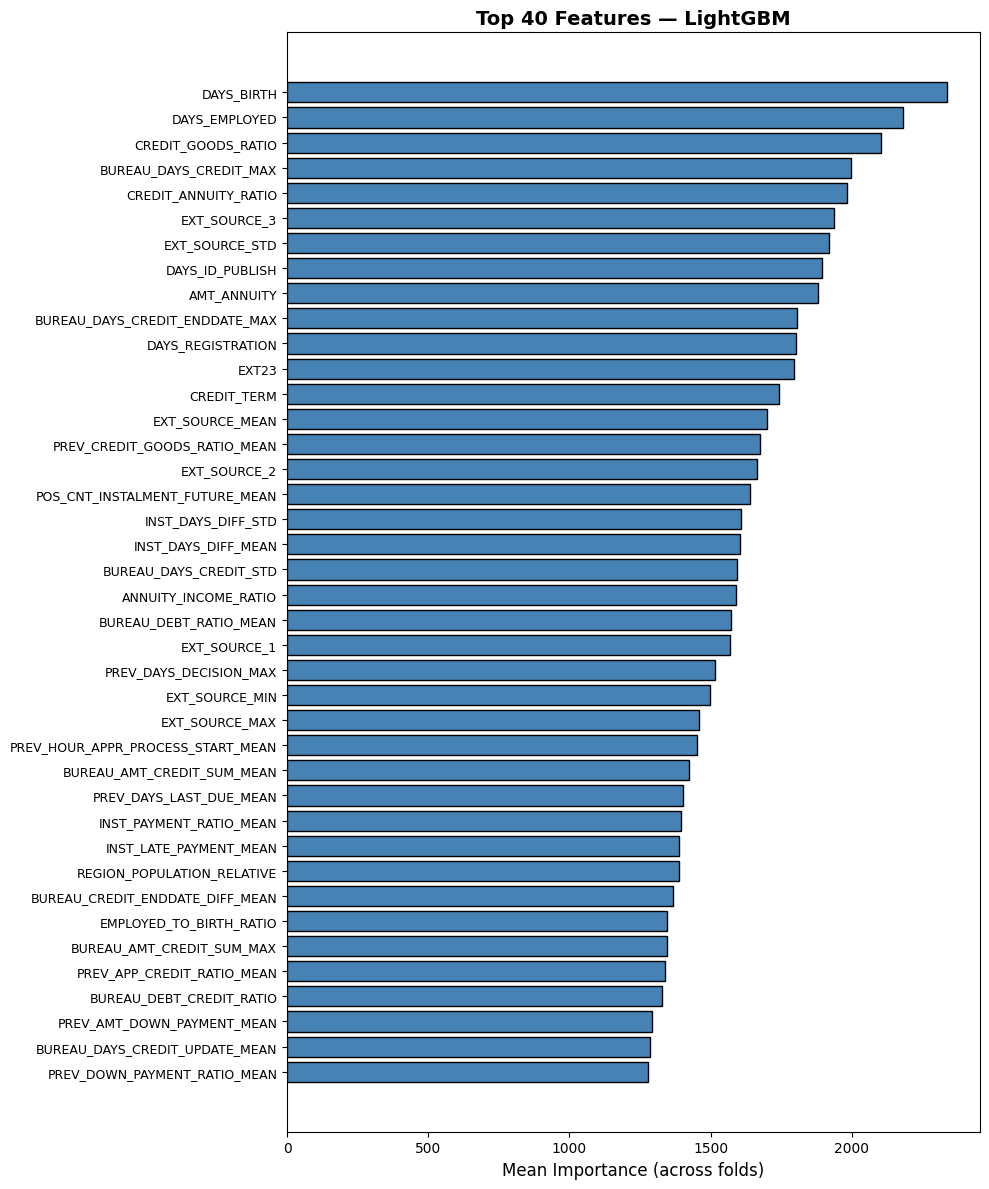

In [ ]:
# Cell 15 — Feature Importance (top 40)
mean_imp = feature_imp.groupby('feature')['importance'].mean().sort_values(ascending=False)
top40 = mean_imp.head(40)

plt.figure(figsize=(10, 12))
plt.barh(range(len(top40)), top40.values, color='steelblue', edgecolor='black')
plt.yticks(range(len(top40)), top40.index, fontsize=9)
plt.xlabel('Mean Importance (across folds)', fontsize=12)
plt.title('Top 40 Features — LightGBM', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/kaggle/working/feature_importance.png', dpi=120)
plt.show()

In [ ]:
# Cell 16 — Final Summary
print('='*65)
print('HOME CREDIT DEFAULT RISK — MAX SCORE ATTEMPT')
print('='*65)
print(f'\nData sources: 6 tables (including previous_application.csv)')
print(f'Total features: {app_train.shape[1]}')
print(f'\nLightGBM OOF AUC ({N_FOLDS}-fold): {lgb_oof_auc:.5f}')
print(f'XGBoost  OOF AUC ({N_FOLDS_XGB}-fold): {xgb_oof_auc:.5f}')
print(f'Blended  OOF AUC:          {blend_auc:.5f}')
print(f'\nBlend weights:  LGB={w_lgb:.3f}  XGB={w_xgb:.3f}')
print(f'\nSubmission: {output_path} ({len(submission)} rows)')
print('='*65)

HOME CREDIT DEFAULT RISK — MAX SCORE ATTEMPT

Data sources: 6 tables (including previous_application.csv)
Total features: 319

LightGBM OOF AUC (10-fold): 0.79152
XGBoost  OOF AUC (5-fold): 0.79093
Blended  OOF AUC:          0.79216

Blend weights:  LGB=0.500  XGB=0.500

Submission: /kaggle/working/submission.csv (48744 rows)
